In [1]:
from renderer import GaussianScene
import torch

scene = torch.load('../checkpoints/gmf_refined_best.pt', weights_only=False)
print(scene.keys())

means = scene['means'].float().contiguous()
scales = scene['log_scales'].float().contiguous()
intensity = scene['log_amplitudes'].float().reshape(-1, 1).contiguous()
quat = scene['quaternions'].float().contiguous()

# print(f'intensity: min {intensity.min()}, median {intensity.median()}, max {intensity.max()}')
Gaussian = GaussianScene(means=means, scales=scales, intensity=intensity, quaternions=quat)
cov_world = Gaussian.covariance_world()

odict_keys(['means', 'log_scales', 'quaternions', 'log_amplitudes'])


In [2]:
from turtle import width

from renderer import Camera
camera = Camera(
    width=800,
    height=600,
    fx=800,
    fy=800,
    cx=400,
    cy=300,
    R_wc=torch.eye(3, device=Gaussian.device),
    t_wc=torch.zeros(3, device=Gaussian.device)
)

from renderer import look_at
dir = look_at(
    eye=torch.tensor([0.0, 0.0, 1.0], device=Gaussian.device),
    target=torch.tensor([0.0, 0.0, 0.0], device=Gaussian.device),
    up=torch.tensor([0.0, 1.0, 0.0], device=Gaussian.device)
)

dir

(tensor([[ 1., -0.,  0.],
         [ 0.,  1.,  0.],
         [ 0.,  0., -1.]], device='cuda:0'),
 tensor([0., 0., 1.], device='cuda:0'))

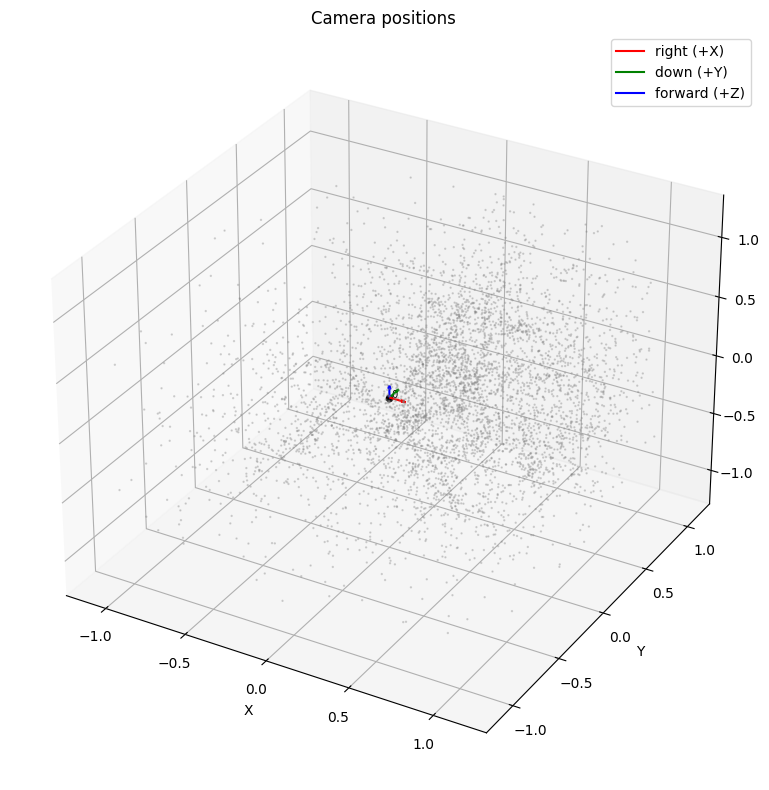

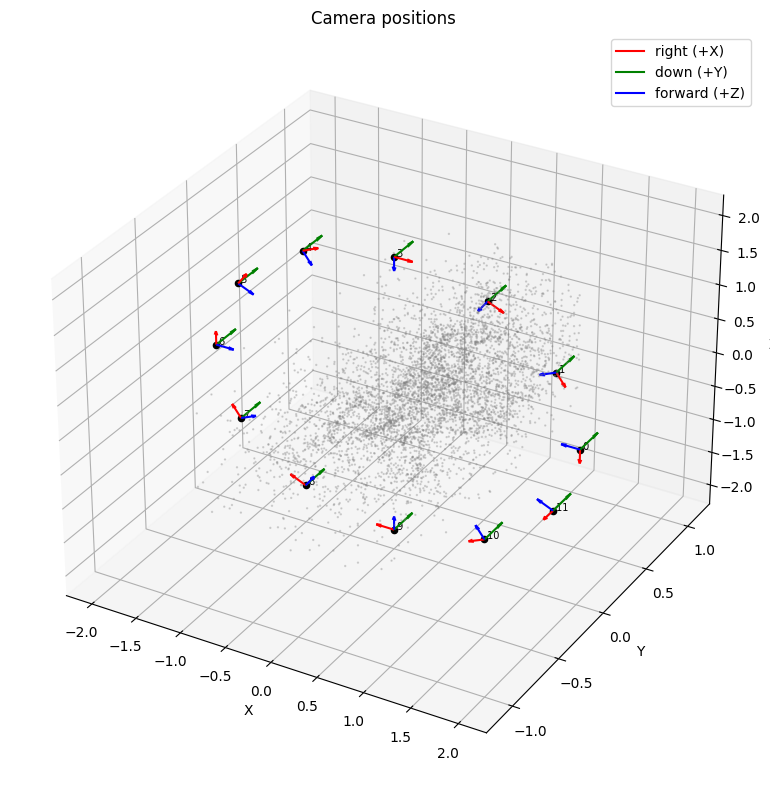

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_cameras(cameras: list, means=None, scale=0.1, title="Camera positions"):
    """
    cameras: list of Camera objects (renderer.Camera)
    means:   optional Gaussian means tensor (N,3) to overlay point cloud
    scale:   size of camera frustum axes
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for i, cam in enumerate(cameras):
        # Camera center in world coords: C = -R_wc.T @ t_wc
        R = cam.R_wc.cpu().numpy()
        t = cam.t_wc.cpu().numpy()
        C = -R.T @ t  # world position of camera

        # Camera axes in world coords (columns of R_wc.T = R_cw)
        right   = R.T[:, 0] * scale  # x-axis (red)
        down    = R.T[:, 1] * scale  # y-axis (green)
        forward = R.T[:, 2] * scale  # z-axis (blue)

        ax.scatter(*C, c='black', s=20, zorder=5)
        ax.quiver(*C, *right,   color='red',   length=1, normalize=False)
        ax.quiver(*C, *down,    color='green', length=1, normalize=False)
        ax.quiver(*C, *forward, color='blue',  length=1, normalize=False)
        ax.text(C[0], C[1], C[2], f" {i}", fontsize=7)

    if means is not None:
        pts = means.cpu().numpy()
        # subsample for speed
        idx = np.random.choice(len(pts), min(5000, len(pts)), replace=False)
        ax.scatter(pts[idx, 0], pts[idx, 1], pts[idx, 2],
                   c='gray', s=0.5, alpha=0.3, label='Gaussians')

    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title)
    # red=right, green=down, blue=forward (camera +Z)
    from matplotlib.lines import Line2D
    legend = [Line2D([0],[0], color='red',   label='right (+X)'),
              Line2D([0],[0], color='green', label='down (+Y)'),
              Line2D([0],[0], color='blue',  label='forward (+Z)')]
    ax.legend(handles=legend)
    plt.tight_layout()
    plt.savefig('camera_positions.png', dpi=300)

# Single camera
plot_cameras([camera], means=means)

# Multiple cameras (e.g. orbit ring)
import torch, math
cameras = []
for angle in range(0, 360, 30):
    rad = math.radians(angle)
    eye = torch.tensor([2*math.cos(rad), 0.0, 2*math.sin(rad)], device=Gaussian.device)
    R, t = look_at(eye, target=torch.zeros(3, device=Gaussian.device))
    cameras.append(Camera(width=800, height=600, fx=800, fy=800, cx=400, cy=300, R_wc=R, t_wc=t))

plot_cameras(cameras, means=means, scale=0.2)



/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/torch/utils/cpp_extension.py:1965: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


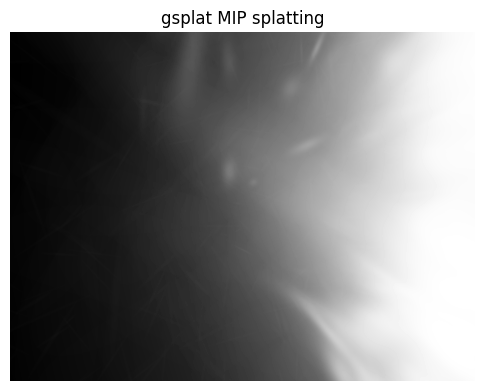

In [8]:
import sys; sys.path.insert(0, 'renderer')
from render_gsplat import render_gsplat
import matplotlib.pyplot as plt

img = render_gsplat(Gaussian, camera)

plt.figure(figsize=(6, 6))
plt.imshow(img.cpu().numpy(), cmap='gray')
plt.axis('off')
plt.title('gsplat MIP splatting')
plt.show()


In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np, torch, torch.nn.functional as F, math
from gsplat.rendering import rasterization

# ---------------------------------------------------------------------------
# Aspect-ratio correction
# Training normalises every axis to [-1,1] independently, so Z=100 gets the
# same range as X=813 → Z is stretched by 813/100 ≈ 8×.
#
# The 3-D covariance in normalised space is:  Σ = R @ diag(s²) @ Rᵀ
# In physical space it becomes:               Σ_phys = A @ Σ @ Aᵀ
#   where A = diag(aspect).
#
# We decompose  L = A @ R @ diag(s)  via SVD → L = U @ diag(σ) @ Vᵀ
# so that  Σ_phys = L @ Lᵀ = U @ diag(σ²) @ Uᵀ
# giving corrected rotation R' = U  and corrected scales s' = σ.
# ---------------------------------------------------------------------------
VOL_SHAPE = (100, 647, 813)   # (Z, Y, X) voxels of the source volume

def correct_aspect(means_n, log_scales_n, quats_n, vol_shape):
    Z, Y, X = vol_shape
    aspect = torch.tensor([X/X, Y/X, Z/X], dtype=torch.float32, device=means_n.device)

    # corrected means (simple scaling)
    means_p = means_n * aspect[None, :]

    # build rotation matrices from quaternions (wxyz)
    q = F.normalize(quats_n, dim=-1)
    w, x, y, z = q[:, 0], q[:, 1], q[:, 2], q[:, 3]
    N = q.shape[0]
    R = torch.zeros(N, 3, 3, dtype=q.dtype, device=q.device)
    R[:, 0, 0] = 1 - 2*(y*y + z*z);  R[:, 0, 1] = 2*(x*y - w*z);  R[:, 0, 2] = 2*(x*z + w*y)
    R[:, 1, 0] = 2*(x*y + w*z);       R[:, 1, 1] = 1 - 2*(x*x + z*z); R[:, 1, 2] = 2*(y*z - w*x)
    R[:, 2, 0] = 2*(x*z - w*y);       R[:, 2, 1] = 2*(y*z + w*x);  R[:, 2, 2] = 1 - 2*(x*x + y*y)

    s = torch.exp(log_scales_n)                            # (N, 3)
    A = torch.diag(aspect)                                 # (3, 3)

    # L = A @ R @ diag(s)  →  Σ_phys = L @ Lᵀ
    L = (A[None] @ R) * s[:, None, :]                     # (N, 3, 3)

    U, sigma, Vh = torch.linalg.svd(L)                    # U:(N,3,3) sigma:(N,3)

    # Ensure U is a proper rotation (det=+1); flip last col where det=-1
    d = torch.linalg.det(U)                               # (N,)
    U = U.clone()
    U[:, :, -1] *= d[:, None]                             # (N, 3, 3)

    scales_p = sigma                                       # (N, 3) always ≥ 0

    # Convert rotation matrix U back to wxyz quaternion
    # Shepperd's method
    trace = U[:, 0, 0] + U[:, 1, 1] + U[:, 2, 2]
    quats_p = torch.zeros(N, 4, dtype=q.dtype, device=q.device)
    # w, x, y, z
    quats_p[:, 0] = torch.sqrt((trace + 1).clamp(min=0)) / 2
    quats_p[:, 1] = (U[:, 2, 1] - U[:, 1, 2]) / (4 * quats_p[:, 0].clamp(min=1e-6))
    quats_p[:, 2] = (U[:, 0, 2] - U[:, 2, 0]) / (4 * quats_p[:, 0].clamp(min=1e-6))
    quats_p[:, 3] = (U[:, 1, 0] - U[:, 0, 1]) / (4 * quats_p[:, 0].clamp(min=1e-6))
    quats_p = F.normalize(quats_p, dim=-1)

    return means_p.contiguous(), scales_p.contiguous(), quats_p.contiguous()


# --- Load splats (run once) ---
raw       = scene
means, scales_c, quats_c = correct_aspect(
    raw['means'].float(),
    raw['log_scales'].float(),
    raw['quaternions'].float(),
    VOL_SHAPE,
)
opacities = torch.exp(raw['log_amplitudes'].float()).squeeze(-1).clamp(0, 1).contiguous()
colors    = torch.ones(means.shape[0], 1, device=means.device)


@torch.no_grad()
def render_at(azimuth, elevation, radius=1.5, W=512, H=512):
    az, el = math.radians(azimuth), math.radians(elevation)
    eye = torch.tensor([
        radius * math.cos(el) * math.sin(az),
        radius * math.sin(el),
        radius * math.cos(el) * math.cos(az),
    ], dtype=torch.float32, device=means.device)

    forward = F.normalize(-eye, dim=0)
    right   = F.normalize(torch.cross(forward, torch.tensor([0., 1., 0.], device=means.device)), dim=0)
    up      = torch.cross(right, forward, dim=0)
    R = torch.stack([right, -up, forward], dim=0)
    t = -R @ eye

    E = torch.eye(4, device=means.device)
    E[:3, :3] = R
    E[:3,  3] = t

    fy = 0.5 * H / math.tan(math.radians(45) / 2)
    K  = torch.tensor([[fy, 0, W/2], [0, fy, H/2], [0, 0, 1]],
                      device=means.device, dtype=torch.float32)

    rc, _, _ = rasterization(
        means, quats_c, scales_c, opacities, colors,
        E[None], K[None], W, H,
        eps2d=0.3, sh_degree=None, packed=True,
        rasterize_mode="antialiased", render_mode="RGB",
    )
    return rc[0, ..., 0].clamp(0, 1).cpu().numpy()


az  = widgets.IntSlider(min=0,    max=360, step=5,   value=45,  description='Azimuth')
el  = widgets.IntSlider(min=-80,  max=80,  step=5,   value=20,  description='Elevation')
rad = widgets.FloatSlider(min=0.1, max=5,  step=0.1, value=1.5, description='Radius')
out = widgets.Output()

def _update(*_):
    img = render_at(az.value, el.value, rad.value)
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        plt.tight_layout()
        plt.show()

az.observe(_update, 'value')
el.observe(_update, 'value')
rad.observe(_update, 'value')
display(widgets.VBox([widgets.HBox([az, el, rad]), out]))
_update()
